### Imports et configuration

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

### Chargement des données

In [2]:
def load_metadata_and_counts(dataset_dir: str) -> pd.DataFrame:
    """Lit les fichiers labels YOLO pour compter les insectes par image."""
    base_path = Path(dataset_dir)
    images_dir = base_path / "images"
    labels_dir = base_path / "labels"
    
    data = []
    
    for img_path in images_dir.glob("*.*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue
            
        jour = img_path.name[:8]
        label_path = labels_dir / img_path.with_suffix(".txt").name
        
        insect_count = 0
        if label_path.exists():
            with open(label_path, 'r') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]
                insect_count = len(lines)
                
        data.append({
            "image_name": img_path.name,
            "image_path": str(img_path),
            "jour": jour,
            "insect_count": insect_count
        })
        
    return pd.DataFrame(data)

# Chargement depuis le sous-dossier de 'data' (ajuste le ../ si ton notebook est à la racine)
DATASET_DIR = "../data/merged_filtered_dataset" 

print("Analyse des fichiers et comptage des insectes en cours...")
df = load_metadata_and_counts(DATASET_DIR)

# Afficher les 5 premières lignes pour vérifier interactivement
df.head()

Analyse des fichiers et comptage des insectes en cours...


,image_name,image_path,jour,insect_count
0,20221006_09-03-49-024129_raw_jpg.rf.4df65bba71...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
1,20221006_09-11-26-908410_raw_jpg.rf.d17c0ef063...,..\data\merged_filtered_dataset\images\2022100...,20221006,0
2,20221006_09-14-31-840309_raw_jpg.rf.28d2caeab7...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
3,20221006_09-14-34-972005_raw_jpg.rf.5a5d09316b...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
4,20221006_09-14-44-434197_raw_jpg.rf.b0129cf391...,..\data\merged_filtered_dataset\images\2022100...,20221006,1


### Séparation des données (ajustement / test)

In [3]:
# Définition stricte des ensembles d'ajustement et de test
jours_ajustement = ['20221006', '20221007', '20221012', '20221017']
jours_test = ['20221018', '20221019', '20221020']

# Séparation du DataFrame
df_ajustement = df[df['jour'].isin(jours_ajustement)].copy()
df_test = df[df['jour'].isin(jours_test)].copy()

print(f"Images pour l'ajustement (développement) : {len(df_ajustement)}")
print(f"Images pour le test (évaluation finale)  : {len(df_test)}")

Images pour l'ajustement (développement) : 702
Images pour le test (évaluation finale)  : 399


### Implémentation d'un Background Subtractor (MOG2)

In [ ]:
def apply_mog2_on_day(df: pd.DataFrame, day: str, learning_rate: float = 0.05):
    """
    Applique la soustraction de fond MOG2 sur une journée entière.
    learning_rate: définit la vitesse à laquelle le modèle "oublie" l'ancien fond.
    """
    # Tri chronologique indispensable pour un algorithme temporel
    df_day = df[df['jour'] == day].sort_values("image_name")
    
    # Initialisation de MOG2
    # history: nombre d'images précédentes utilisées pour modéliser le fond
    # varThreshold: seuil de variance pour décider si un pixel est au premier plan
    backSub = cv2.createBackgroundSubtractorMOG2(history=10, varThreshold=50, detectShadows=True)
    
    # Noyau pour le nettoyage morphologique (un carré de 3x3 pixels)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    
    results = []
    
    for _, row in df_day.iterrows():
        img = cv2.imread(row['image_path'])
        if img is None: 
            continue
            
        # Léger flou pour réduire le grain de l'image
        img_blur = cv2.GaussianBlur(img, (5, 5), 0)
        
        # Application du soustracteur
        fg_mask_raw = backSub.apply(img_blur, learningRate=learning_rate)
        
        # Élimination des ombres (MOG2 met les ombres en gris (127), on veut que du binaire 0/255)
        _, fg_mask_no_shadows = cv2.threshold(fg_mask_raw, 200, 255, cv2.THRESH_BINARY)
        
        # Nettoyage du bruit (Morphology OPEN : érosion puis dilatation)
        fg_mask_clean = cv2.morphologyEx(fg_mask_no_shadows, cv2.MORPH_OPEN, kernel)
        
        results.append({
            'image_name': row['image_name'],
            'original': img,
            'mask_raw': fg_mask_raw,
            'mask_clean': fg_mask_clean
        })
        
    return results

### Visualisation des masques créés sur le jeu d'ajustement

Traitement de la journée 20221017 avec MOG2...


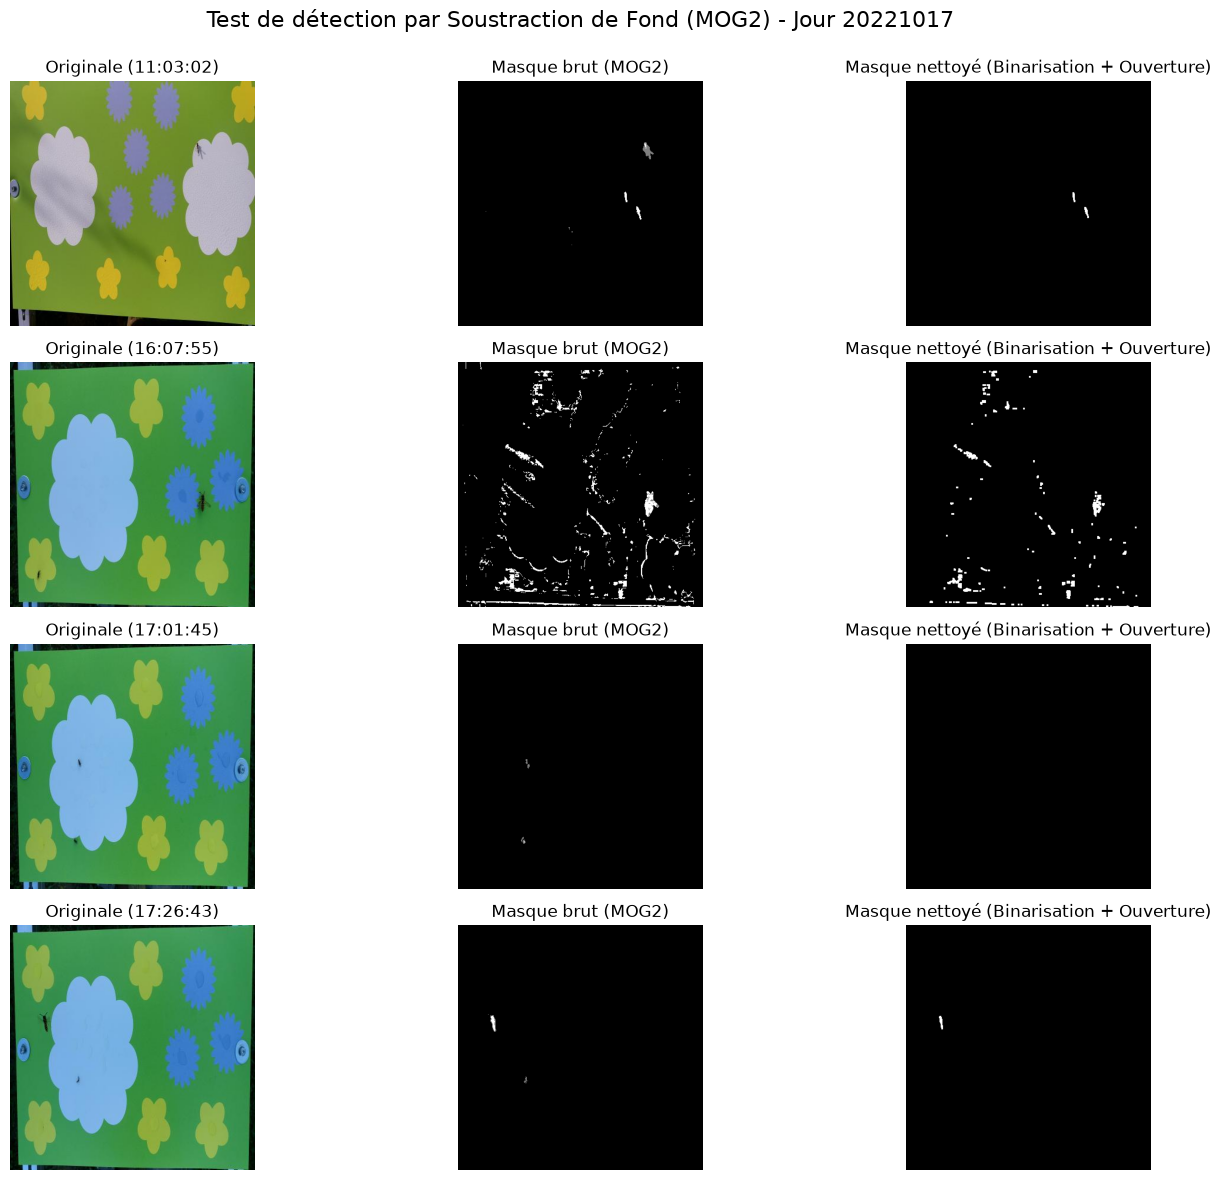

In [8]:
# Sélection d'un jour de notre set d'ajustement
jour_cible = '20221017'
print(f"Traitement de la journée {jour_cible} avec MOG2...")

resultats_mog2 = apply_mog2_on_day(df_ajustement, jour_cible, learning_rate=0.05)

# Affichage de 4 images réparties dans le temps
indices_a_afficher = np.linspace(2, len(resultats_mog2) - 2, 4, dtype=int)

fig, axes = plt.subplots(len(indices_a_afficher), 3, figsize=(15, 12))
fig.suptitle(f"Test de détection par Soustraction de Fond (MOG2) - Jour {jour_cible}", fontsize=16)

for i, idx in enumerate(indices_a_afficher):
    res = resultats_mog2[idx]
    heure = res['image_name'][9:17].replace('-', ':')
    
    # Image originale
    axes[i, 0].imshow(cv2.cvtColor(res['original'], cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"Originale ({heure})")
    axes[i, 0].axis('off')
    
    # Masque brut (avec ombres en gris et bruit)
    axes[i, 1].imshow(res['mask_raw'], cmap='gray')
    axes[i, 1].set_title("Masque brut (MOG2)")
    axes[i, 1].axis('off')
    
    # Masque nettoyé binarisé
    axes[i, 2].imshow(res['mask_clean'], cmap='gray')
    axes[i, 2].set_title("Masque nettoyé (Binarisation + Ouverture)")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()